In [1]:
from argparse import ArgumentParser
import xarray as xr
from matplotlib import pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys

sys.path.insert(
    1, "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation"
)
import plot_utils as plot
import numpy as np



def create_folder_if_not_exists(folder):
    from pathlib import Path

    Path(folder).mkdir(parents=True, exist_ok=True)


def get_temporal_index_in_dataset(timestamp, ds):
    """
    Returns the integer index of a given timestamp in an xarray Dataset
    that may use non-Gregorian calendars (e.g., 360_day).

    timestamp: cftime.Datetime object or a string parseable by cftime
    ds: xarray.Dataset or DataArray with a 'time' coordinate
    """

    # Iterate over time coordinates to find match
    for i, t in enumerate(ds.time.values):
        if t == timestamp:
            return i

    # If not found, raise error
    raise ValueError(f"Timestamp {timestamp} not found in dataset time axis.")


def get_true_data_matching_forecast_timestamps(
    ds_truth, ds_forecast, prediction_steps
):
    """
    prediction_steps should be 0 based -> 0 means using the first prediction of the model for that timestamp
    """
    first_timestamp_forecast = ds_forecast.time[0].values
    last_timestamp_forecast = ds_forecast.time[-1].values
    idx_truth_first = (
        get_temporal_index_in_dataset(first_timestamp_forecast, ds_truth)
        + prediction_steps
        + 1
    )
    idx_truth_last = (
        get_temporal_index_in_dataset(last_timestamp_forecast, ds_truth)
        + prediction_steps
        + 1
    )
    new_forecast = ds_forecast.copy().isel(
        prediction_timedelta=prediction_steps
    )
    new_truth = ds_truth.isel(
        time=slice(idx_truth_first, idx_truth_last + 1)
    ).isel(time=slice(0, None, 2))
    new_forecast = new_forecast.sortby("time")
    _, index = np.unique(new_forecast["time"], return_index=True)
    new_forecast = new_forecast.isel(time=np.sort(index))

    for t in range(len(new_forecast.time.values) - 1):
        if (
            not str(
                new_forecast.time.values[t + 1] - new_forecast.time.values[t]
            )
            == "12:00:00"
        ):
            print(
                f"Error with {new_forecast.time.values[t]} and {new_forecast.time.values[t+1]}"
            )
    new_forecast = new_forecast.assign_coords({"time": new_truth["time"]})
    return new_truth, new_forecast


def get_stacked_true_data_matching_forecast_timestamps(ds_truth, ds_forecast):
    """
    prediction_steps should be 0 based -> 0 means using the first prediction of the model for that timestamp
    """
    first_timestamp_forecast = ds_forecast.time[0].values
    last_timestamp_forecast = ds_forecast.time[-1].values
    idx_truth_first = get_temporal_index_in_dataset(
        first_timestamp_forecast, ds_truth
    )
    idx_truth_last = get_temporal_index_in_dataset(
        last_timestamp_forecast, ds_truth
    )
    new_forecast = ds_forecast.copy()
    new_truth = ds_truth.isel(
        time=slice(idx_truth_first, idx_truth_last + 1)
    ).isel(time=slice(0, None, 2))
    new_forecast = new_forecast.sortby("time")
    _, index = np.unique(new_forecast["time"], return_index=True)
    new_forecast = new_forecast.isel(time=np.sort(index))
    new_forecast = new_forecast.chunk({"latitude": -1, "longitude": -1, "time": 50})
    new_truth = new_truth.chunk({"latitude": -1, "longitude": -1, "time": 50})
    # for t in range(len(new_forecast.time.values)-1):
    #     if not str(new_forecast.time.values[t+1] - new_forecast.time.values[t]) == '12:00:00':
    #         print(f'Error with {new_forecast.time.values[t]} and {new_forecast.time.values[t+1]}')
    # new_forecast = new_forecast.assign_coords({'time': new_truth['time']})
    return new_truth, new_forecast


def build_truth_with_leadtime(truth_ds, max_lead_steps=40):
    """
    truth_ds: Dataset with dimension (time, lat, lon, level)
    Creates a dataset with dimension (time, prediction_timedelta, lat, lon, level)

    lead step k uses truth_ds shifted by k steps forward in time.
    """
    truth_ds = truth_ds.chunk({"time": 50})
    lead_times = np.arange(1, max_lead_steps + 1)

    # Build stacked truth array
    truth_list = []
    for k in lead_times:
        truth_shifted = truth_ds.shift(
            time=-k
        )  # shift backwards so truth[t,k] = truth[t+k]
        truth_list.append(truth_shifted)

    # Combine along new dimension
    truth_with_lead = xr.concat(truth_list, dim="prediction_timedelta")

    # Assign actual timedelta
    truth_with_lead = truth_with_lead.assign_coords(
        prediction_timedelta=xr.DataArray(
            (lead_times * np.timedelta64(6, "h")).astype("timedelta64[ns]"),
            dims=("prediction_timedelta",),
        )
    )

    # Drop times near the end that became NaN
    truth_with_lead = truth_with_lead.dropna(dim="time", how="any")

    return truth_with_lead

In [2]:
folder = '/hkfs/work/workspace/scratch/xo8179-ukesm/global_2100_equiangular_wp_conservative_perturbation'

In [3]:
ds = xr.open_zarr(folder+'/old_fields.zarr')
ds = ds.sortby("time")
selected = ds.sel(time="2100")

In [4]:
print(selected)

<xarray.Dataset> Size: 2GB
Dimensions:                      (time: 1440, longitude: 128, latitude: 64,
                                  level: 6)
Coordinates:
  * latitude                     (latitude) float64 512B -90.0 -87.14 ... 90.0
  * level                        (level) float32 24B 200.0 300.0 ... 850.0 925.0
  * longitude                    (longitude) float64 1kB 0.0 2.812 ... 357.2
  * time                         (time) object 12kB 2100-01-01 00:00:00 ... 2...
Data variables: (12/14)
    geopotential_500             (time, longitude, latitude) float32 47MB dask.array<chunksize=(720, 32, 16), meta=np.ndarray>
    geopotential_at_surface      (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    land_sea_mask                (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    mean_sea_level_pressure      (time, longitude, latitude) float32 47MB dask.array<chunksize=(720, 32, 16), meta=np.ndarray>
    relati

In [5]:
# Select levels
target_levels = [500, 700]  # adjust if level coordinate uses ints

# Define region
lat_min, lat_max = -20, 20

# Define perturbation amount
TEMP_PERTURB = 5  # Kelvin

# Create a copy of the temperature variable with perturbation applied
# We use .where(...) to selectively modify only the desired region+levels
temp = ds["temperature"]

lat = ds.latitude
weights = np.exp(-(lat / 10)**2)  # Gaussian decay

perturb_field = TEMP_PERTURB * weights

perturbed_temp = temp.where(
    ~(
        temp.level.isin(target_levels)
        &
        (temp.latitude >= lat_min)
        &
        (temp.latitude <= lat_max)
    ),
    other=temp + perturb_field)

# Replace the temperature variable in the dataset
ds_perturbed = ds.copy()
ds_perturbed["temperature"] = perturbed_temp


/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/venv/lib64/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


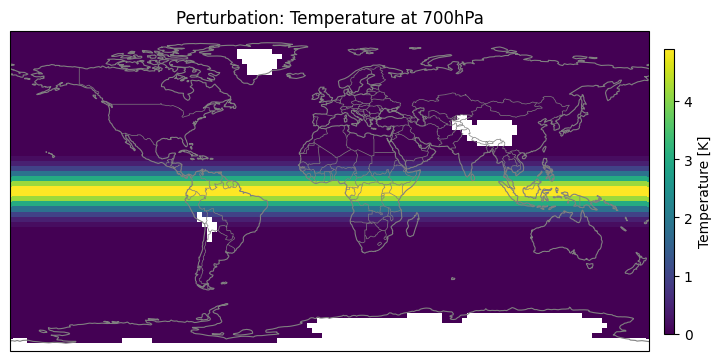

In [6]:
plot.plot_single_plot(plot.get_masked_ukesm_data(ds_perturbed["temperature"].sel(level=700)-ds["temperature"].sel(level=700), plevel=700).mean(dim='time').T, f'Perturbation: Temperature at 700hPa', 'Temperature [K]', None, 'viridis', "", f'', show=True)

In [28]:

# Save to a NEW Zarr store
ds_perturbed.to_zarr(folder+"/fields.zarr", mode="w")

In [29]:
ds = xr.open_zarr(folder+'/old_forcing.zarr')
ds = ds.sortby("time")
selected = ds.sel(time="2100")

In [31]:
print(selected)
print(selected.dtypes)

<xarray.Dataset> Size: 236MB
Dimensions:                        (time: 1440, longitude: 128, latitude: 64,
                                    forcing_var: 5)
Coordinates:
  * forcing_var                    (forcing_var) object 40B 'toa_incident_rad...
  * latitude                       (latitude) float64 512B -90.0 -87.14 ... 90.0
  * longitude                      (longitude) float64 1kB 0.0 2.812 ... 357.2
  * time                           (time) object 12kB 2100-01-01 00:00:00 ......
Data variables:
    __xarray_dataarray_variable__  (time, longitude, latitude, forcing_var) float32 236MB dask.array<chunksize=(40, 128, 64, 5), meta=np.ndarray>
Frozen({'__xarray_dataarray_variable__': dtype('float32')})


In [32]:
for v in selected.variables:
    selected[v].encoding.clear()
selected.to_zarr(folder+"/forcing.zarr", mode="w")